# Mini-Project 3
## Lecture 8 - Computer Arithmetic & Numerical Accuracy
### Milestone 1

In [1]:
# Packages
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Adds mandelbrot-nsc to sys.path so lecture_files can be imported
sys.path.append(str(Path("..").resolve()))

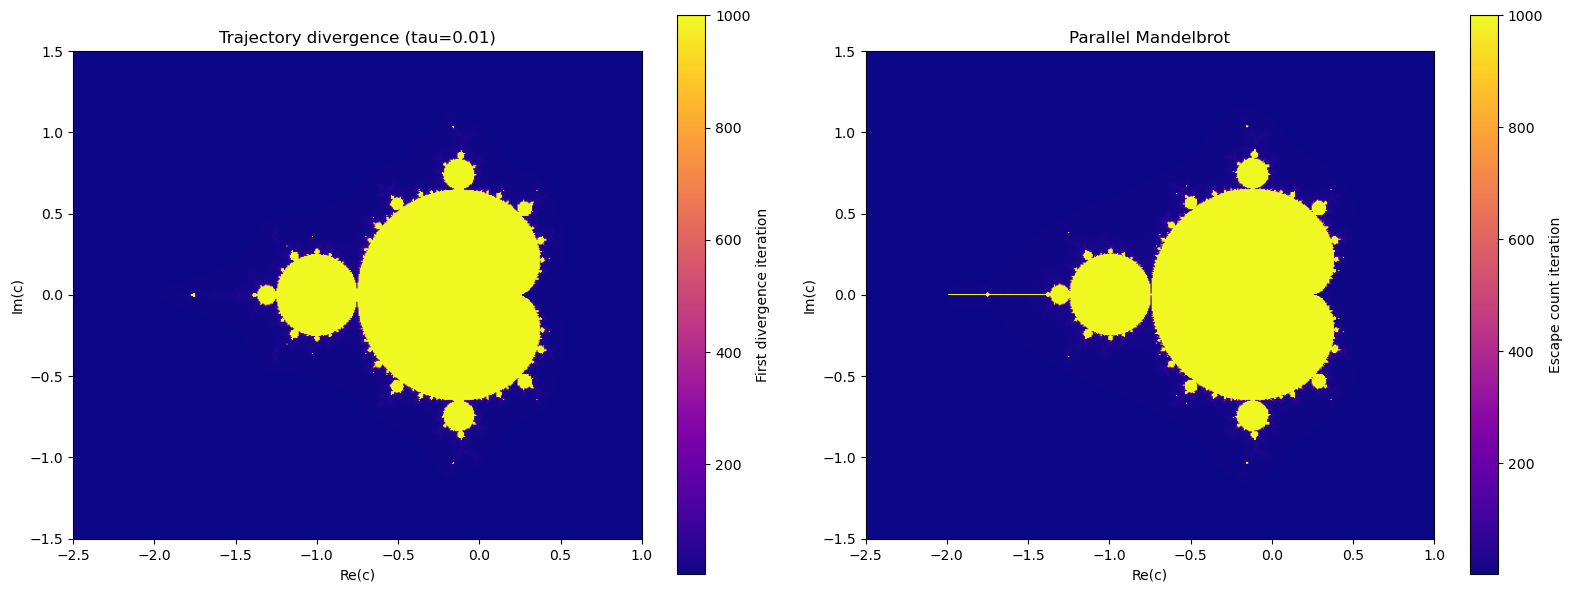

Pixels diverging before max_iter: 224628
Total pixels: 262144
The fraction of pixels diverging before max_iter: 0.86


In [15]:
import lecture_py_files.mandelbrot_8 as mb8 
import lecture_py_files.mandelbrot_5 as mb5

N = 512
#x_dim = (-0.7530, -0.7490)
#y_dim = (0.0990, 0.1030)
#x_dim = (-0.76, -0.74)
#y_dim = (0.09, 0.11)
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)
max_iter = 1000
tau = 0.01
n_workers = 4

# Plot trajectory and escape count (parallel mandelbrot) for comparison
diverge = mb8.mandelbrot_trajectory_divergence(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter, tau=tau, plot=False)
result_parallel = mb5.mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter, num_workers=n_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
im0 = axes[0].imshow(diverge, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[0].set_title(f'Trajectory divergence (tau={tau})')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')
fig.colorbar(im0, ax=axes[0], label='First divergence iteration')
im1 = axes[1].imshow(result_parallel, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[1].set_title('Parallel Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
fig.colorbar(im1, ax=axes[1], label='Escape count iteration')
plt.tight_layout()
plt.show()

#Fraction diverging before max_iter
count = np.sum(diverge < max_iter)
pixels = N**2
fraction = count / (pixels)
print(f'Pixels diverging before max_iter: {count}')
print(f'Total pixels: {pixels}')
print(f'The fraction of pixels diverging before max_iter: {fraction:.2f}')    

Observations to make:

▶ What fraction of pixels diverge before max iter?

- The fraction of pixels diverging before max_iter is 0.86 (for the full frame):
    ```python
    x_dim = (-2.5, 1.0)
    y_dim = (-1.5, 1.5)
    ```

▶ Where do trajectories diverge early?
- Early divergence appears in the dark blue regions outside the Mandelbrot set and along its boundary filaments. These are exactly the areas where orbits escape quickly rather than staying bounded.

▶ Does early divergence correlate with high escape iteration counts?
- It correlates inversely. Early divergence corresponds to low escape iteration counts. Conversely, the bright yellow regions (high iteration counts) indicate points that remain bounded much longer (inside or near the Mandelbrot set), which does not have early divergence.